In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest

In [3]:
df = pd.read_csv("../datasets/HDFS_2k_structured.csv")

In [4]:
df["Message_Length"] = df["Message"].str.len()

df["Has_Block_ID"] = df["Message"].str.contains(
    "blk_", regex=False
).astype(int)

df["Has_PacketResponder"] = df["Message"].str.contains(
    "PacketResponder",
    case=False
).astype(int)

df["Has_Error"] = df["Message"].str.contains(
    "error",
    case=False,
    na=False
).astype(int)

df["Is_WARN"] = (df["Level"] == "WARN").astype(int)

In [5]:
features = [
    "Message_Length",
    "Has_Block_ID",
    "Has_PacketResponder",
    "Has_Error",
    "Is_WARN"
]

X = df[features]

In [6]:
model = IsolationForest(
    contamination=0.05,
    random_state=42
)

model.fit(X)

df["Anomaly"] = model.predict(X)

In [7]:
counts = df["Anomaly"].value_counts()

print(counts)

Anomaly
 1    1912
-1      88
Name: count, dtype: int64


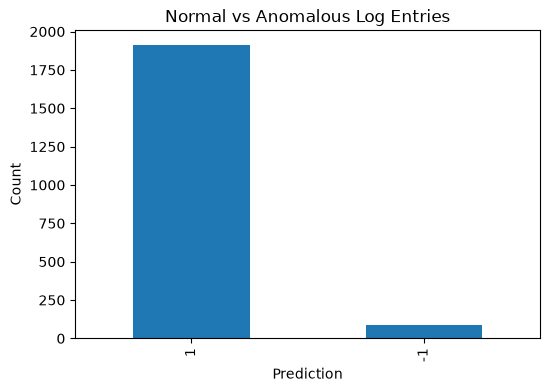

In [8]:
plt.figure(figsize=(6,4))

counts.plot(kind="bar")

plt.title("Normal vs Anomalous Log Entries")

plt.xlabel("Prediction")

plt.ylabel("Count")

plt.show()


## Observation: Normal vs Anomalous Log Entries

The Isolation Forest model classified the majority of log messages as normal while identifying a smaller subset as anomalous.

This behaviour is expected because anomalies are typically rare events in system log data.


In [9]:
anomalies = df[df["Anomaly"] == -1]

In [10]:
component_counts = anomalies["Component"].value_counts()

print(component_counts)

Component
dfs.DataNode$DataXceiver:        35
dfs.DataNode$PacketResponder:    30
dfs.DataBlockScanner:            20
dfs.FSNamesystem:                 3
Name: count, dtype: int64


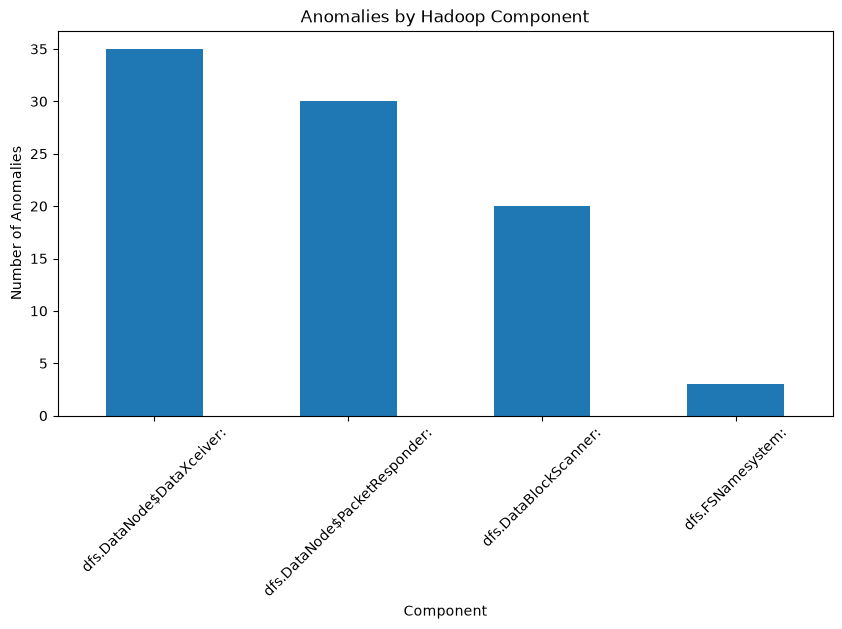

In [11]:
plt.figure(figsize=(10,5))

component_counts.plot(kind="bar")

plt.title("Anomalies by Hadoop Component")

plt.xlabel("Component")

plt.ylabel("Number of Anomalies")

plt.xticks(rotation=45)

plt.show()

## Observation: Anomalies by Hadoop Component

The detected anomalies are not distributed equally across Hadoop components.

Some components contribute a larger proportion of anomalous log messages than others, suggesting that these components exhibit more statistically unusual logging behaviour within the HDFS dataset.

In [12]:
level_counts = anomalies["Level"].value_counts()

print(level_counts)

Level
INFO    53
WARN    35
Name: count, dtype: int64


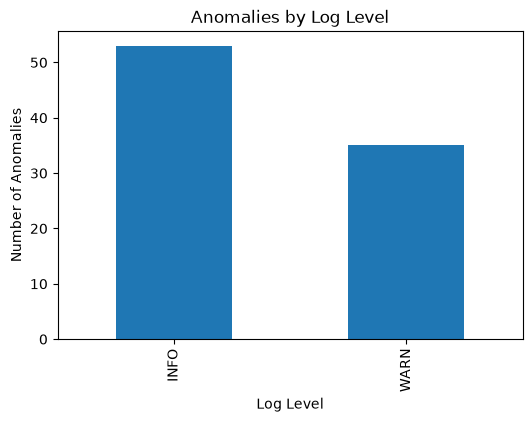

In [13]:
plt.figure(figsize=(6,4))

level_counts.plot(kind="bar")

plt.title("Anomalies by Log Level")

plt.xlabel("Log Level")

plt.ylabel("Number of Anomalies")

plt.show()

## Observation: Anomalies by Log Level

The detected anomalies are distributed across different log severity levels.

This indicates that statistical anomalies are not necessarily limited to WARN messages. The Isolation Forest model is capable of identifying unusual patterns even within INFO log entries based on the engineered features rather than relying solely on log severity.

In [14]:
normal_logs = df[df["Anomaly"] == 1]

anomaly_logs = df[df["Anomaly"] == -1]

In [15]:
print("Average normal message length:",
      normal_logs["Message_Length"].mean())

print("Average anomaly message length:",
      anomaly_logs["Message_Length"].mean())

Average normal message length: 93.95135983263599
Average anomaly message length: 127.42045454545455


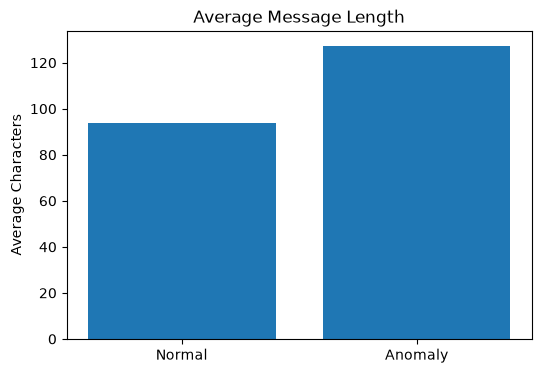

In [16]:
average_lengths = [
    normal_logs["Message_Length"].mean(),
    anomaly_logs["Message_Length"].mean()
]

labels = ["Normal", "Anomaly"]

plt.figure(figsize=(6,4))

plt.bar(labels, average_lengths)

plt.title("Average Message Length")

plt.ylabel("Average Characters")

plt.show()

## Observation: Average Message Length

The average message length of anomalous log entries is noticeably higher than that of normal log entries.

This suggests that longer log messages tend to contain more complex or unusual system events, making message length a useful feature for anomaly detection within the HDFS dataset.

# Conclusion

The Isolation Forest model successfully identified anomalous log entries within the HDFS dataset.

The evaluation showed that:

- Most log entries were classified as normal.
- The dfs.DataNode$DataXceiver component contained the highest number of detected anomalies.
- Anomalies occurred across multiple log severity levels.
- Anomalous log messages were, on average, significantly longer than normal log messages.

These findings provide an initial understanding of the behaviour of the Isolation Forest model and establish a foundation for the next stage of this research, which focuses on explaining model predictions using Explainable AI techniques such as SHAP.